# Objective
To make a CNN classifier with best possible metrics on the cifar 10 dataset. In the process we will use and explore different model architectures

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [2]:
# Import necessary libraries
import pandas as pd
from keras.layers import Input, Dense, Conv2D, Flatten, Rescaling
from keras.models import Sequential
from src.utils import plot_metrics, plot_feature_maps
import tensorflow as tf
from sklearn.model_selection import train_test_split
from src.model_function import FullyGeneralizedCNN


### Data loader and Dataset

In [3]:
# 1. Load your metadata CSV
df = pd.read_csv("../data/raw/trainLabels.csv")
df['label'] = df['label'].astype('category')
class_names = df['label'].cat.categories.tolist() 
df['label'] = df['label'].cat.codes

# 2. Split your DataFrame with stratification
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label'] # Ensures balanced classes in train/val
)

# 3. Use tf.data to build a fast, modern pipeline from your CSV
def load_and_preprocess_image(filename, label):
    # Safely convert integer/int64 filenames to string tensors
    filename_str = tf.strings.as_string(filename)
    
    # Append the PNG extension
    filename_str = tf.strings.join([filename_str, ".png"]) 
    
    # Join with your base directory path
    img_path = tf.strings.join(["../data/raw/images/", filename_str])
    
    # Read and process the image
    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels=3) 
    img = tf.image.resize(img, (32, 32))
    return img, label

def create_dataset(dataframe):
    filenames = dataframe['id'].values
    labels = dataframe['label'].values
    
    dataset = tf.data.Dataset.from_tensor_slices((filenames, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.cache()
    
    # Removed the duplicate prefetch line here
    dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)
    return dataset

# 4. Generate your final datasets
train_dataset = create_dataset(train_df)
val_dataset = create_dataset(val_df)

### Preparing the Baseline Model

In [4]:
def build_baseline_model():
    baseline_model = Sequential()

    baseline_model.add(Input(shape=(32, 32, 3)))
    baseline_model.add(Rescaling(1./255))
    baseline_model.add(Conv2D(32, (3, 3), use_bias=True, activation="relu"))

    # Classifier Head
    baseline_model.add(Flatten())
    baseline_model.add(Dense(64, use_bias=True, activation="relu"))
    baseline_model.add(Dense(10, activation="softmax"))

    baseline_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    baseline_model_history = baseline_model.fit(train_dataset, validation_data=val_dataset, epochs=10, verbose = 0)

    return baseline_model, baseline_model_history

In [5]:
baseline_model, baseline_model_history = build_baseline_model()

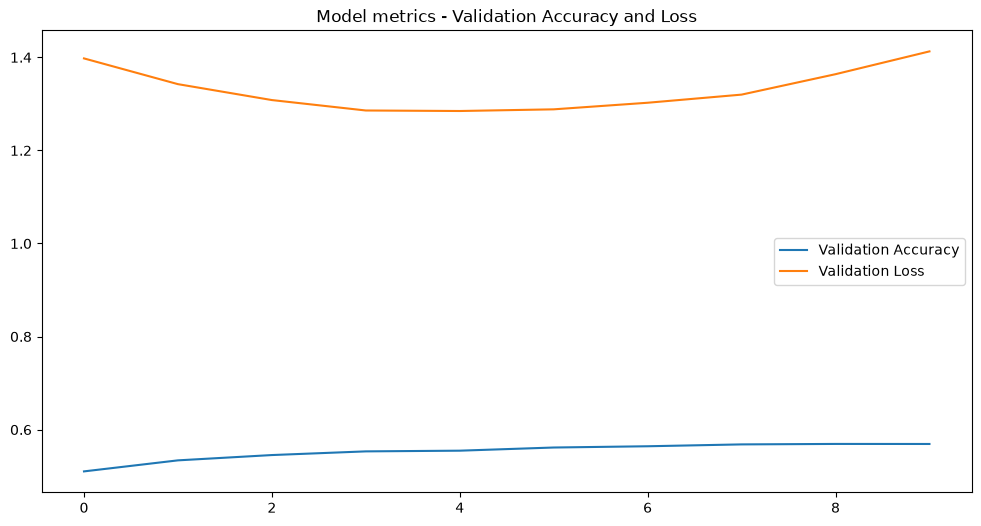

Baseline model accuracy: 56.93%


In [6]:
plot_metrics(baseline_model_history)
baseline_model_accuracy = max(baseline_model_history.history['val_accuracy']) * 100
print(f"Baseline model accuracy: {baseline_model_accuracy:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


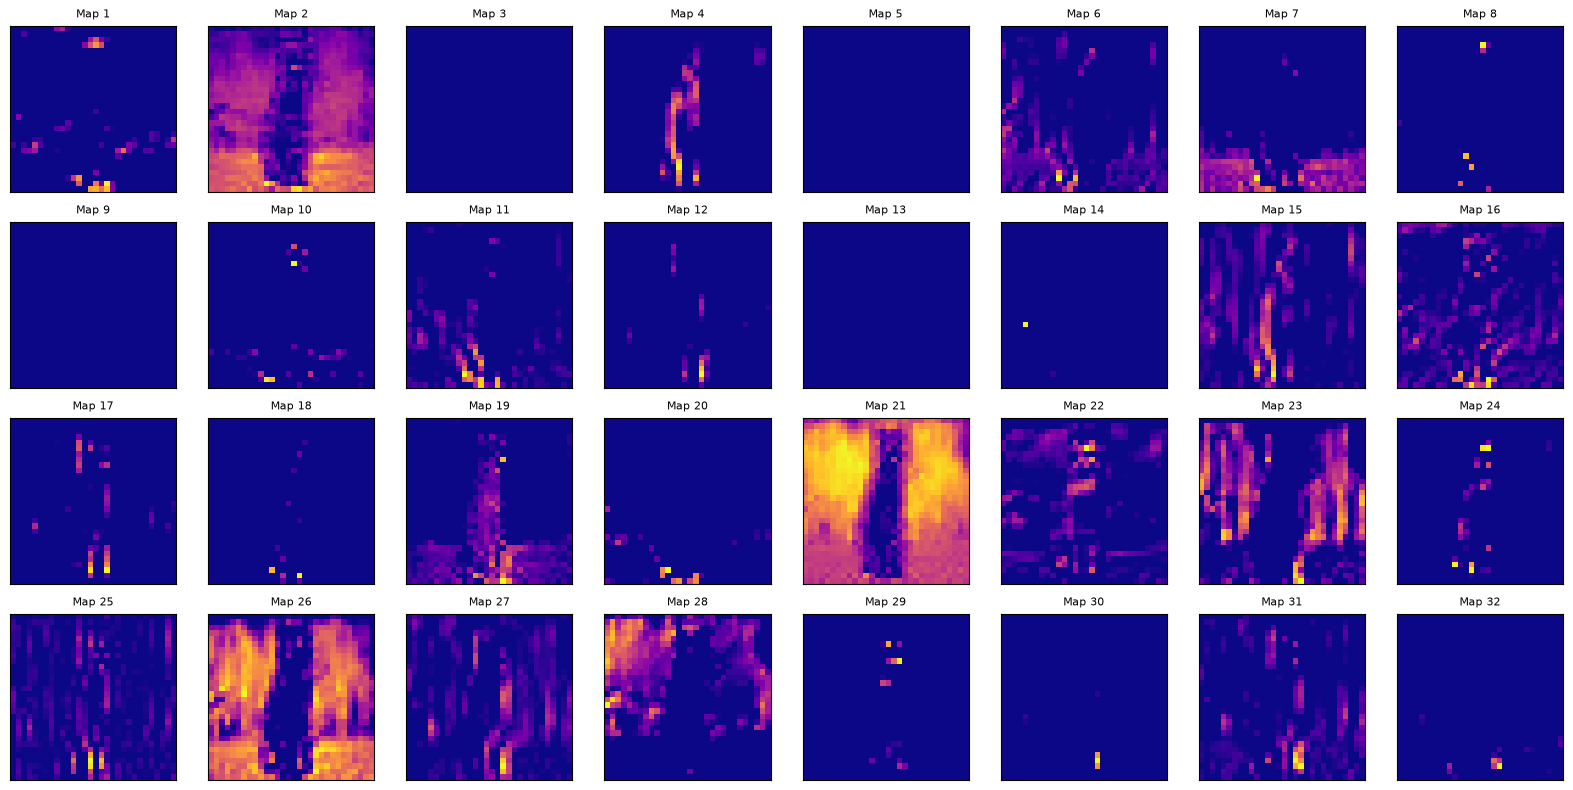

In [7]:
plot_feature_maps(baseline_model, 1, '../data/raw/sample.jpg')

### Observation
Sometimes it gives high accuracies of around 70%+ whereas sometimes performs below 15%. This happens because internal covariate shift and dying relu problems. Sometimes they happen sometimes they not

## Adding BatchNorm and and deepening the CNN model

In [8]:
def handle_case(use_batch_norm, use_max_pooling, strides, padding):
    custom_cnn_model = FullyGeneralizedCNN(use_batch_norm=use_batch_norm, use_max_pooling=use_max_pooling, strides=strides, padding=padding)
    custom_cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    custom_cnn_history = custom_cnn_model.fit(train_dataset, validation_data=val_dataset, epochs=10, verbose=0)
    cnn_model_accuracy = custom_cnn_history.history['val_accuracy'][-1] * 100
    print(f"Custom CNN model accuracy: {cnn_model_accuracy:.2f}%")
    plot_metrics(custom_cnn_history)
    return custom_cnn_model, custom_cnn_history

### 1. Deeper Model without batchNorm and Max Pooling Layer with padding same

Custom CNN model accuracy: 73.82%


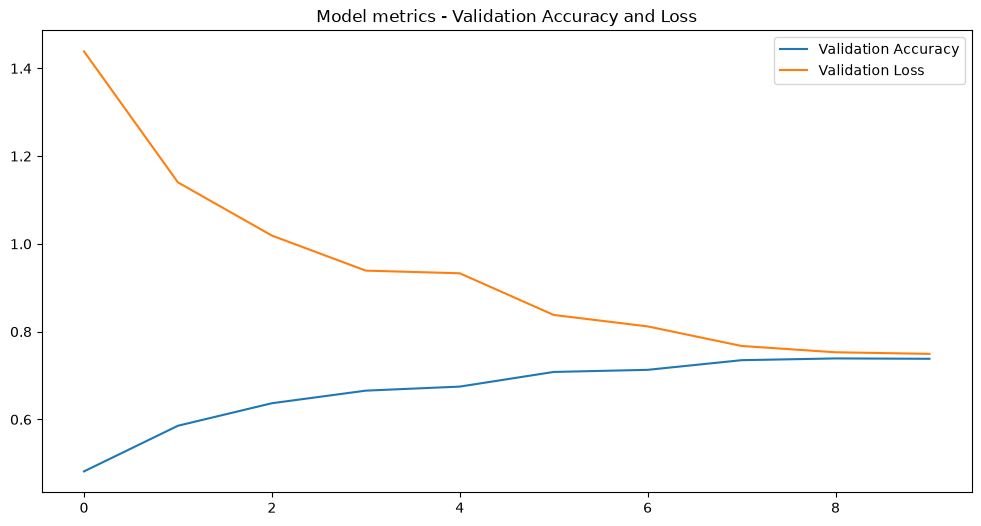

(<Functional name=FullyGeneralizedCNN, built=True>,
 <keras.src.callbacks.history.History at 0x124c3e000>)

In [9]:
handle_case(use_batch_norm=False, use_max_pooling=True, strides=(1, 1), padding="same")

### 2. Deeper Model with batchNorm and Max Pooling Layer with padding same
As without batchNorm dying relu etc problems can occur and that too when the model is big so we will use for every model now

Custom CNN model accuracy: 80.58%


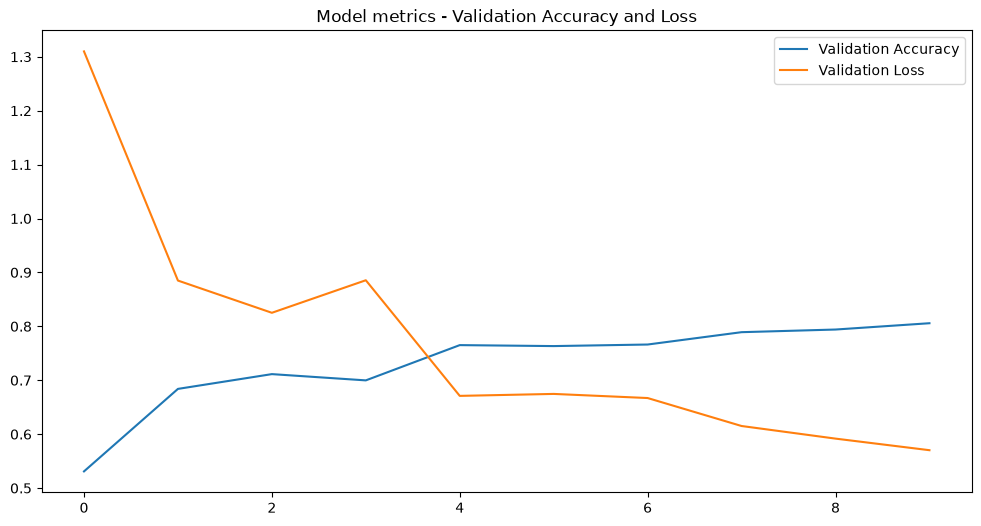

In [10]:
model , history = handle_case(use_batch_norm=True, use_max_pooling=True, strides=(1, 1), padding="same")

### 3. Deeper Model with batchNorm and without Max Pooling Layer with padding same
We wont compress the parametrs by pooling but by increasing the strides of conv layer

Custom CNN model accuracy: 70.86%


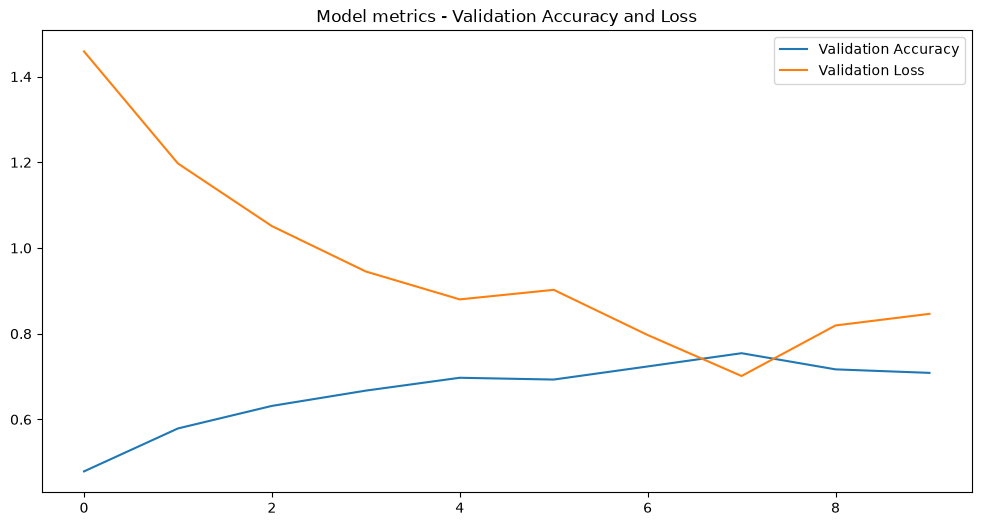

(<Functional name=FullyGeneralizedCNN, built=True>,
 <keras.src.callbacks.history.History at 0x124aad910>)

In [11]:
handle_case(use_batch_norm=True, use_max_pooling=False, strides=(2, 2), padding="same")

### 4. Deeper Model with batchNorm and without Max Pooling Layer with padding valid to find the final metric
We wont compress the parametrs by pooling but by increasing the strides of conv layer

Custom CNN model accuracy: 75.84%


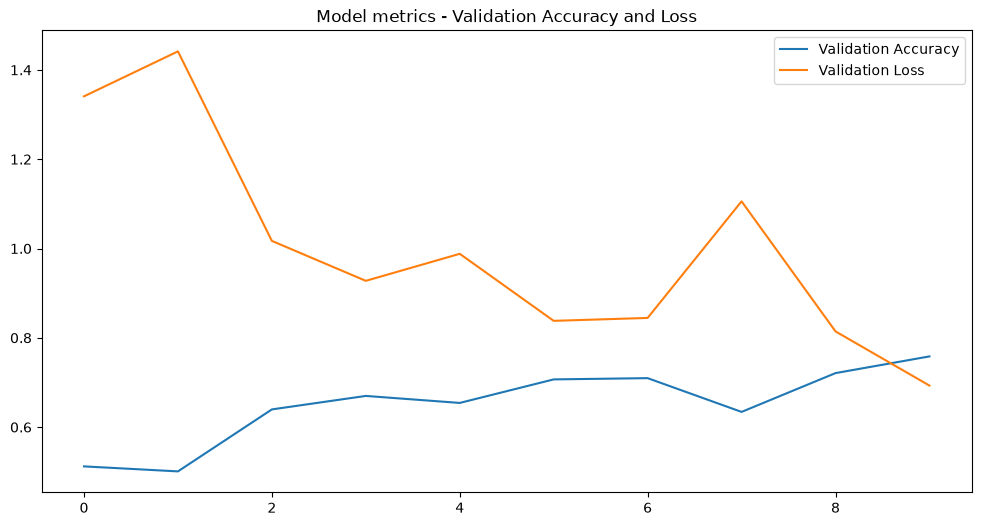

(<Functional name=FullyGeneralizedCNN, built=True>,
 <keras.src.callbacks.history.History at 0x12518a240>)

In [12]:
handle_case(use_batch_norm=True, use_max_pooling=False, strides=(2, 2), padding="valid")

### Model Configuration Results & Analysis

After generalizing the CNN architecture to support dynamic pooling, normalization, and padding strategies, we tested four distinct configurations over 10 epochs.

| Case | Configuration (BatchNorm, Pooling, Strides, Padding) | Validation Accuracy | Curve Observation |
| :--- | :--- | :--- | :--- |
| **1** | `False`, `True`, `(1, 1)`, `"same"` | **73.82%** | **Textbook Smooth:** Perfectly stable convergence. Loss decreases steadily without overfitting. |
| **2** | `True`, `True`, `(1, 1)`, `"same"` | **80.58%** | **Best Performer:** Batch Norm accelerated learning significantly, breaking the 80% threshold. |
| **3** | `True`, `False`, `(2, 2)`, `"same"` | **70.86%** | **Early Overfitting:** Strided convolutions without pooling caused loss to creep up after Epoch 7. |
| **4** | `True`, `False`, `(2, 2)`, `"valid"` | **75.84%** | **Erratic Learning:** Aggressive spatial reduction (`valid` + `strides=2`) led to large spikes in validation loss. |

**Key Takeaway:** The traditional VGG-style approach (Case 2: `strides=(1,1)` with `MaxPooling` and `BatchNormalization`) yields the most robust and highest-performing feature extraction for this dataset. Relying purely on strided convolutions for downsampling (Cases 3 & 4) introduced training instability.

## Plotting feature maps for the winner algo

### Low Level Features

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


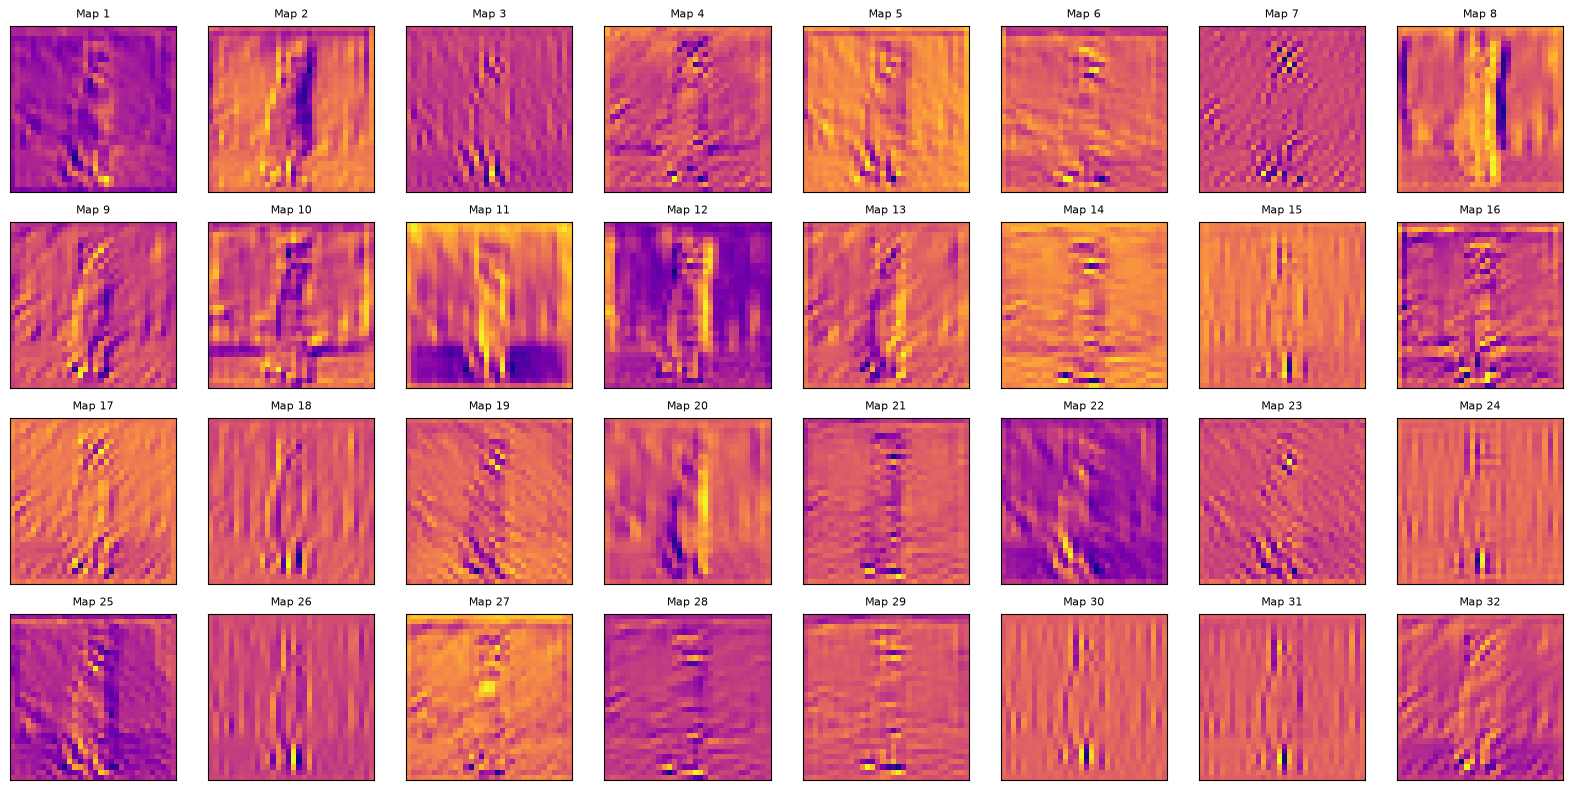

In [19]:
plot_feature_maps(model, 2, '../data/raw/sample.jpg')

### Mid Level Features

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


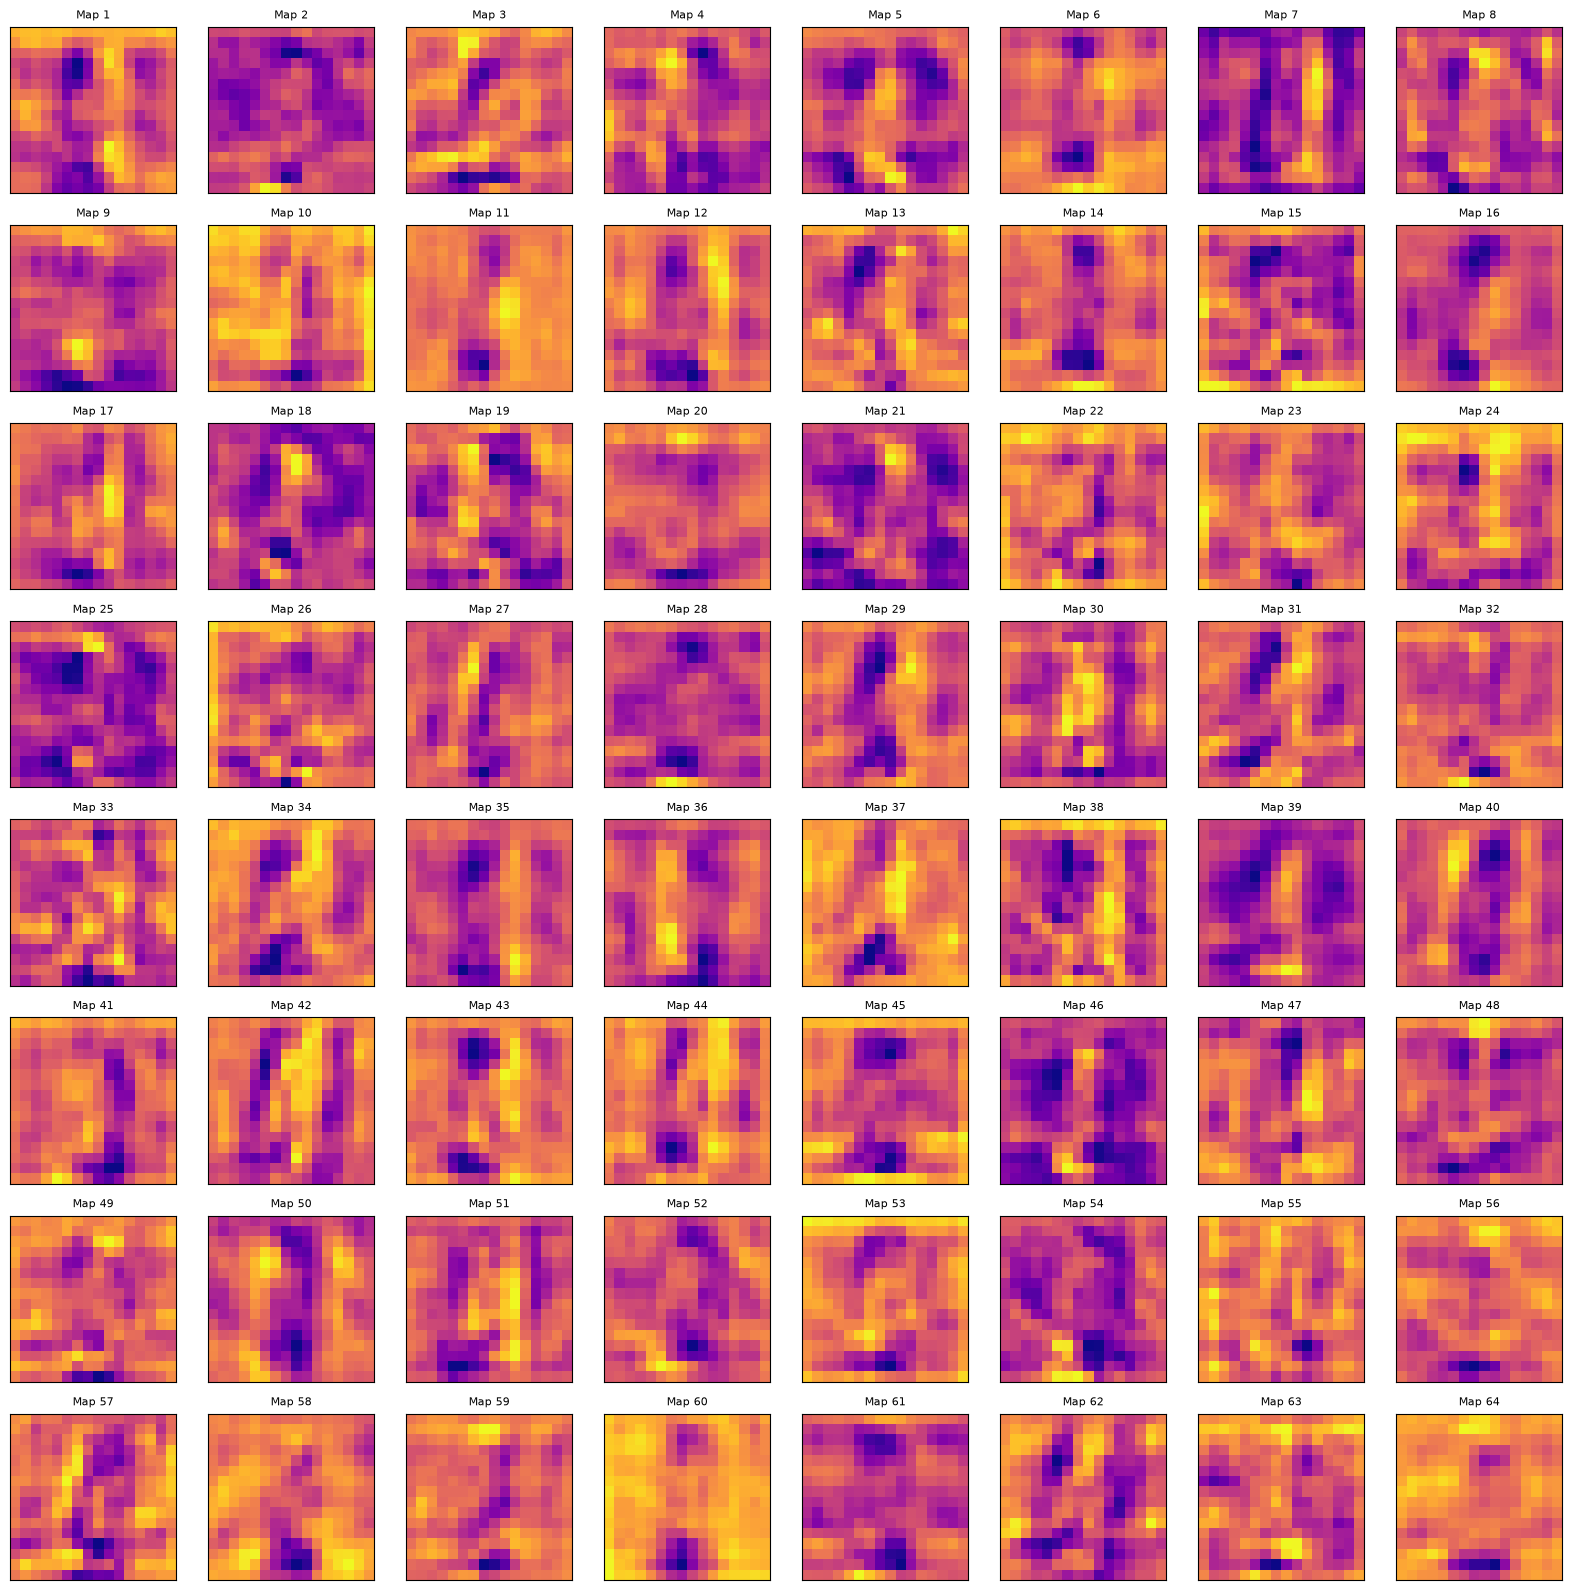

In [20]:
plot_feature_maps(model, 4, '../data/raw/sample.jpg')

### High Level Features

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


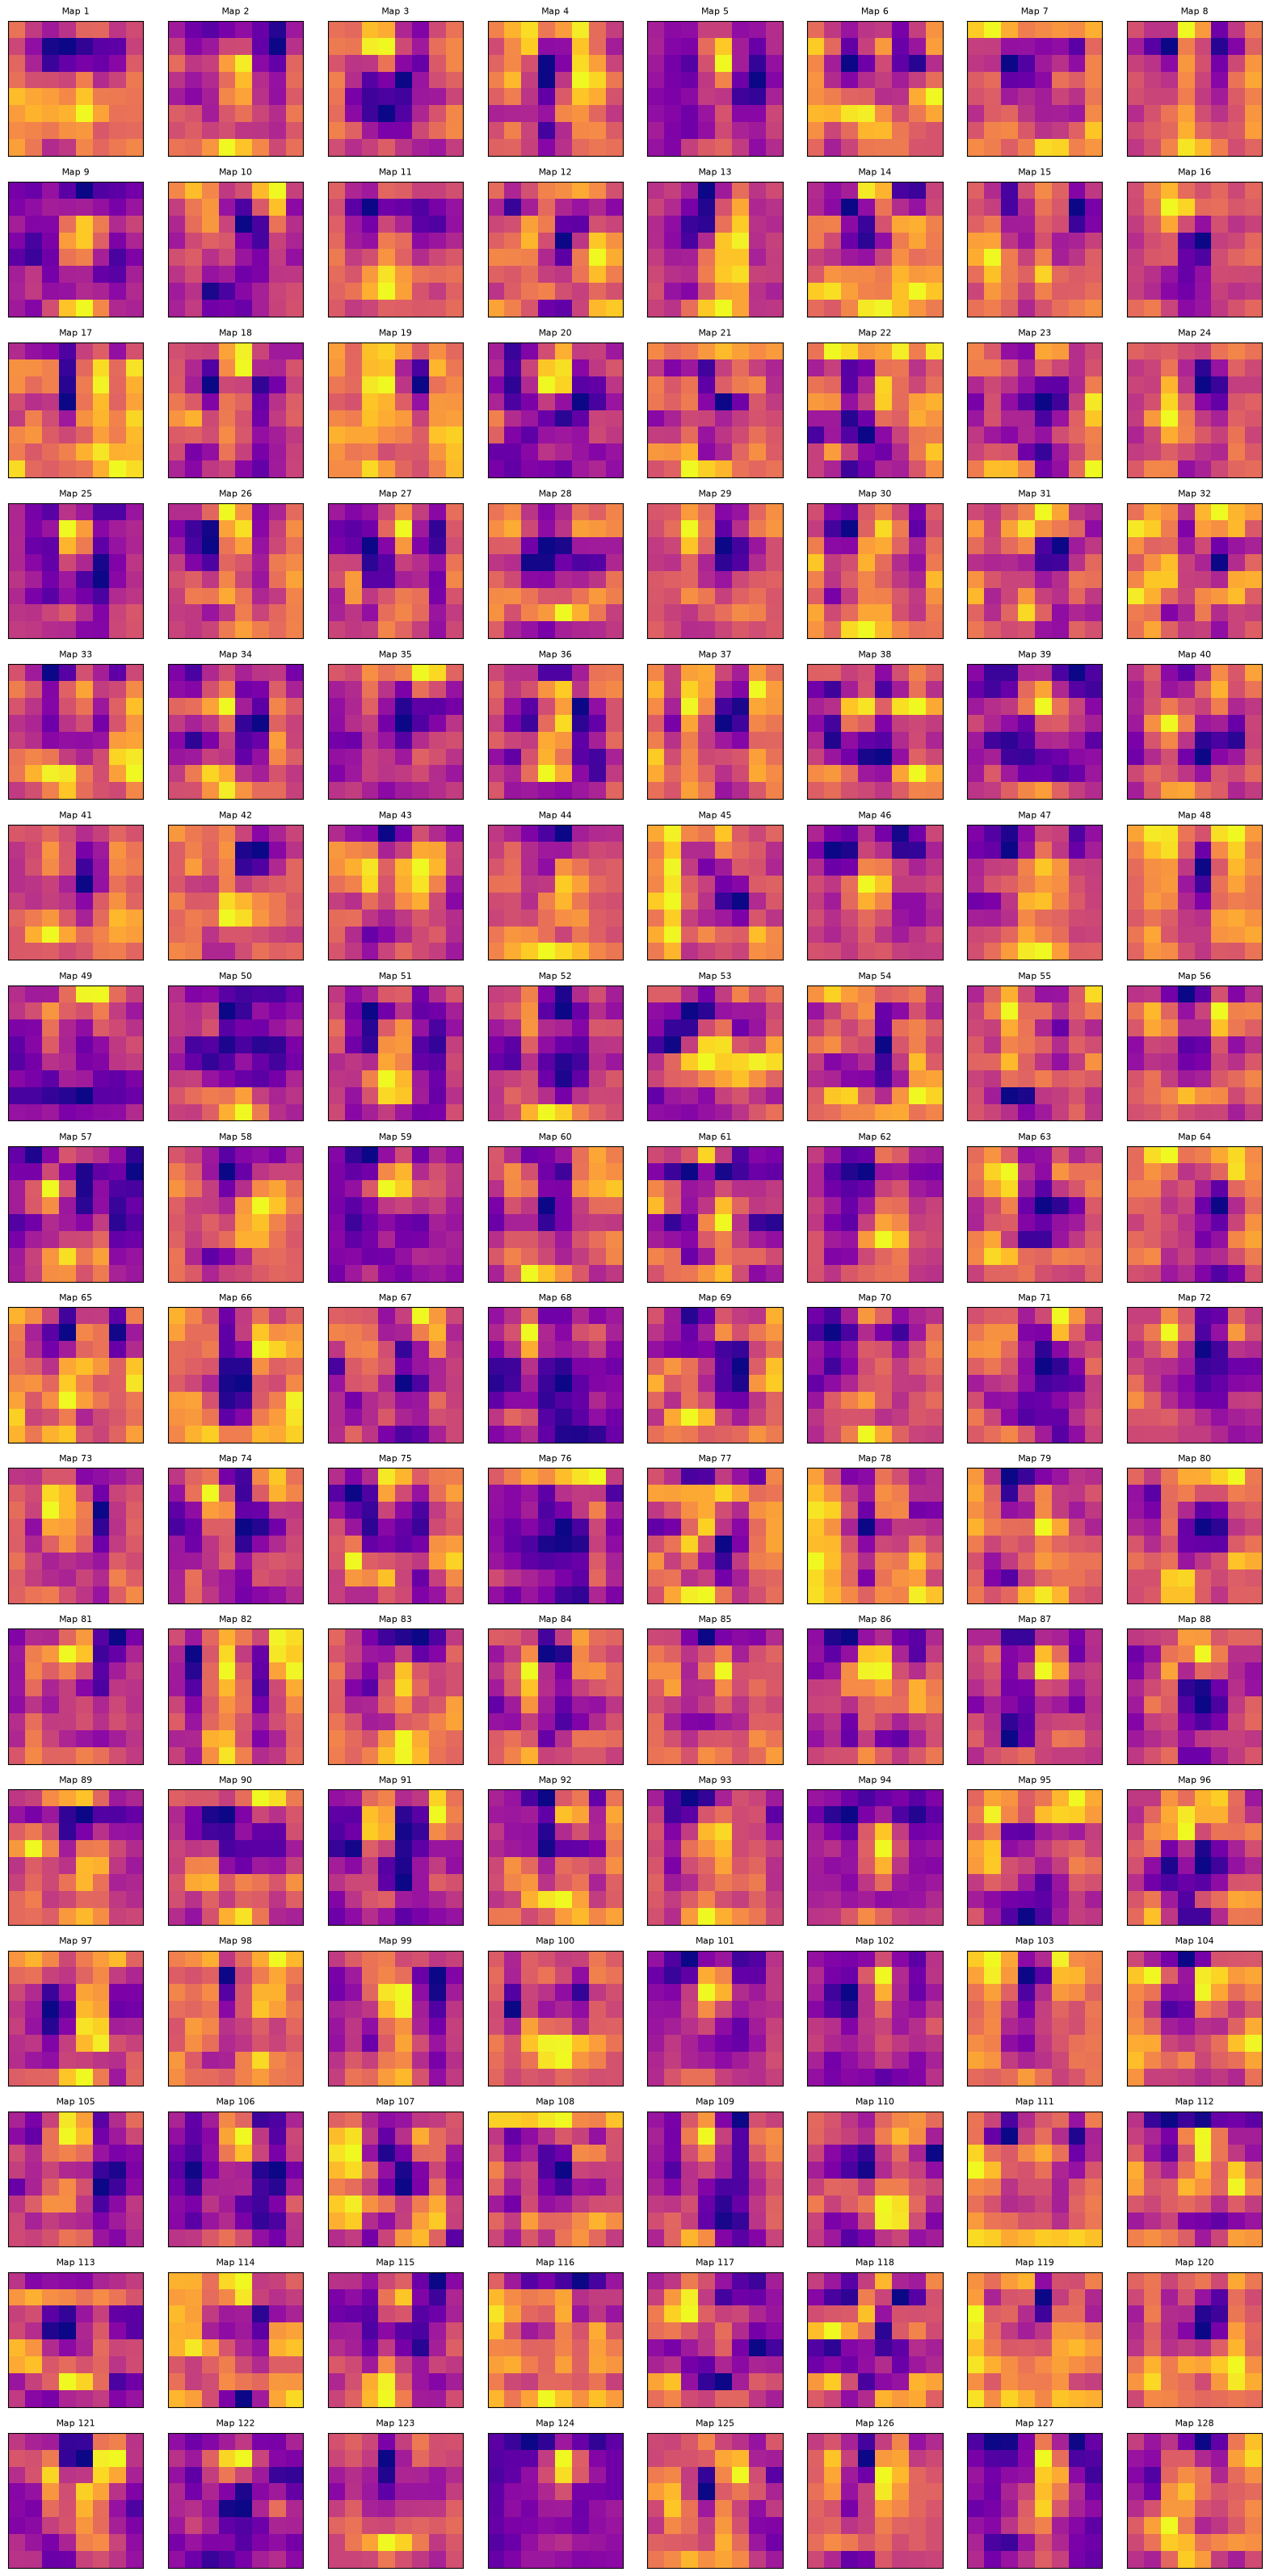

In [21]:
plot_feature_maps(model, 6, '../data/raw/sample.jpg')